In [41]:
import json
import pandas as pd
from pandas import json_normalize
import numpy as np

In [ ]:
# with open('../data/small_friends_info.json', 'r', encoding='utf-8') as f:
#     data = json.load(f)   # data — dict: {id: {...}, ...}

# ids = list(data.keys())
# records = list(data.values())

# df = json_normalize(records, sep='_')  # разворачивает вложенные dict'ы в колонки
# df['user_id'] = ids
# df.set_index('user_id', inplace=True)

# df.to_csv('../data/small_friends_info.csv', encoding='utf-8', index=True)
# print('Saved to data/friends_info.csv')


Saved to data/friends_info.csv


In [43]:
dataset = pd.read_csv('../data/small_friends_info.csv', index_col='user_id')
dataset.head()

,basic_info_id,basic_info_first_name,basic_info_last_name,basic_info_domain,basic_info_is_closed,demographics_sex,demographics_birth_date,demographics_age,demographics_city,demographics_country,...,interests_activities,interests_interests,interests_music,interests_movies,interests_books,interests_games,metadata_data_retrieved,metadata_has_education,metadata_has_career,metadata_interests_count
user_id,,,,,,,,,,,,,,,,,,,,,
163823935,163823935,Владимир,Демченко,NaN,False,мужской,19.11,NaN,Подольск,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.346899,True,False,0
91478379,91478379,Катя,Панкратьева,NaN,False,женский,7.3,NaN,Paris,Франция,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.351597,False,False,0
230631594,230631594,Алексей,Епифанцев,NaN,False,мужской,18.4,NaN,Химки,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.361165,False,False,0
185888968,185888968,Эльдар,Аймалетдинов,NaN,False,мужской,11.10,NaN,Москва,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.346930,False,False,0
184572109,184572109,Таисия,Петрова,NaN,False,женский,29.4,NaN,Москва,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.361096,False,False,0


In [44]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 163823935 to 584995001
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   basic_info_id                          150 non-null    int64  
 1   basic_info_first_name                  150 non-null    object 
 2   basic_info_last_name                   150 non-null    object 
 3   basic_info_domain                      0 non-null      float64
 4   basic_info_is_closed                   150 non-null    bool   
 5   demographics_sex                       150 non-null    object 
 6   demographics_birth_date                129 non-null    object 
 7   demographics_age                       60 non-null     float64
 8   demographics_city                      102 non-null    object 
 9   demographics_country                   118 non-null    object 
 10  education_career_education_university  34 non-null     object 
 1

In [45]:
dataset.shape

(150, 29)

In [46]:
null_col = ['basic_info_domain', 'social_connections_skype', 'social_connections_facebook', 'social_connections_twitter', 'social_connections_instagram']
useless_col = ['basic_info_first_name', 'basic_info_last_name', 'basic_info_is_closed', 'demographics_birth_date', 'demographics_country', 'education_career_education_graduation',
               'education_career_career', 'education_career_universities', 'metadata_data_retrieved', 'metadata_has_education', 'metadata_has_career',
               'interests_activities', 'interests_interests', 'interests_music', 'interests_movies', 'interests_books', 'interests_games', 'metadata_interests_count', 'basic_info_id']

In [47]:
dataset = dataset.drop(columns=null_col)
dataset = dataset.drop(columns=useless_col)

In [48]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 163823935 to 584995001
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   demographics_sex                       150 non-null    object 
 1   demographics_age                       60 non-null     float64
 2   demographics_city                      102 non-null    object 
 3   education_career_education_university  34 non-null     object 
 4   education_career_education_faculty     20 non-null     object 
dtypes: float64(1), object(4)
memory usage: 7.0+ KB


In [49]:
dataset.sample(20)

,demographics_sex,demographics_age,demographics_city,education_career_education_university,education_career_education_faculty
user_id,,,,,
387516654,мужской,20.0,NaN,NaN,NaN
441397508,женский,NaN,Москва,NaN,NaN
583194957,мужской,NaN,NaN,NaN,NaN
505204903,мужской,22.0,Москва,NaN,NaN
435357753,женский,NaN,Москва,РТУ МИРЭА,Институт информационных технологий
87224583,мужской,NaN,Химки,NaN,NaN
465363318,мужской,NaN,NaN,NaN,NaN
258814756,мужской,NaN,NaN,NaN,NaN
432150818,мужской,22.0,NaN,МГТУ им. Н. Э. Баумана (бывш. МВТУ),NaN


<Axes: >

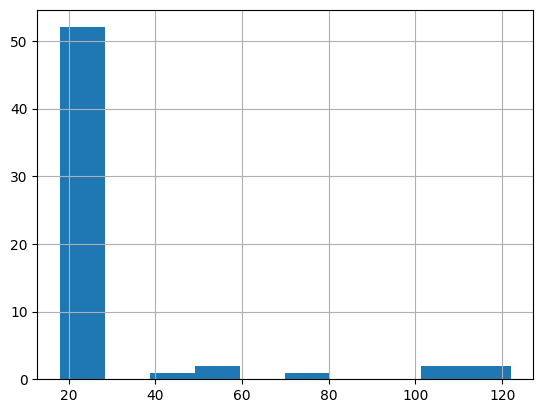

In [50]:
dataset['demographics_age'].hist()

In [51]:
dataset = dataset.loc[(dataset['demographics_age'] < 90) | (dataset['demographics_age'].isna())]

<Axes: >

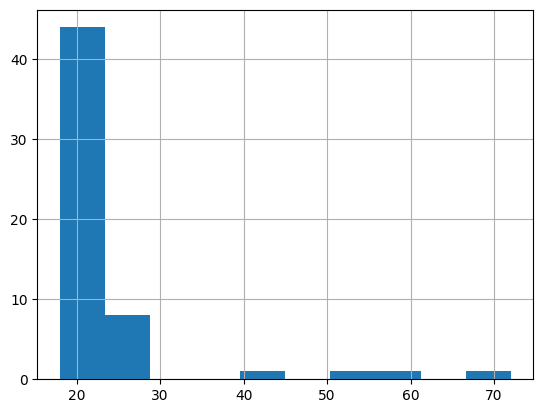

In [52]:
dataset['demographics_age'].hist()

In [53]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 163823935 to 584995001
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   demographics_sex                       146 non-null    object 
 1   demographics_age                       56 non-null     float64
 2   demographics_city                      101 non-null    object 
 3   education_career_education_university  33 non-null     object 
 4   education_career_education_faculty     20 non-null     object 
dtypes: float64(1), object(4)
memory usage: 6.8+ KB


In [54]:
median_age = np.quantile(dataset['demographics_age'].dropna().values, q=0.5)

dataset['demographics_age'] = dataset['demographics_age'].fillna(median_age)

In [55]:
dataset['demographics_city'] = dataset['demographics_city'].fillna('Москва')
dataset['education_career_education_faculty'] = dataset['education_career_education_faculty'].fillna('Неизвестно')
dataset['education_career_education_university'] = dataset['education_career_education_university'].fillna('Неизвестно')

In [56]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 163823935 to 584995001
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   demographics_sex                       146 non-null    object 
 1   demographics_age                       146 non-null    float64
 2   demographics_city                      146 non-null    object 
 3   education_career_education_university  146 non-null    object 
 4   education_career_education_faculty     146 non-null    object 
dtypes: float64(1), object(4)
memory usage: 6.8+ KB


In [57]:
dataset.sample(20)

,demographics_sex,demographics_age,demographics_city,education_career_education_university,education_career_education_faculty
user_id,,,,,
350840991,мужской,22.0,Москва,Неизвестно,Неизвестно
80421291,женский,22.0,Москва,РХТУ им. Д. И. Менделеева,Факультет химико-фармацевтических технологий и...
306509984,мужской,22.0,Москва,Неизвестно,Неизвестно
210813066,мужской,22.0,Москва,РТУ МИРЭА,Неизвестно
361386011,мужской,22.0,Москва,Неизвестно,Неизвестно
387143718,мужской,22.0,Москва,Неизвестно,Неизвестно
432150818,мужской,22.0,Москва,МГТУ им. Н. Э. Баумана (бывш. МВТУ),Неизвестно
227234115,мужской,22.0,Москва,МГТУ им. Н. Э. Баумана (бывш. МВТУ),Неизвестно
195211764,мужской,22.0,Москва,Неизвестно,Неизвестно


In [58]:
dataset['education_career_education_faculty'].value_counts()

education_career_education_faculty
Неизвестно                                                                  126
Институт информационных технологий                                           14
Институт высоких технологий                                                   1
Факультет информационных технологий                                           1
Институт кибербезопасности и цифровых технологий                              1
Факультет химико-фармацевтических технологий и биомедицинских препаратов      1
Философский                                                                   1
Факультет бизнеса «Капитаны»                                                  1
Name: count, dtype: int64

In [59]:
dataset['education_career_education_university'].value_counts()

education_career_education_university
Неизвестно                                     113
РТУ МИРЭА                                       23
МГТУ им. Н. Э. Баумана (бывш. МВТУ)              2
РХТУ им. Д. И. Менделеева                        2
МГУПИ                                            1
МГИМО МИД России                                 1
МИРЭА (до 2015)                                  1
МГУ                                              1
Президентская академия (РАНХиГС, бывш. АНХ)      1
РЭУ им. Г. В. Плеханова                          1
Name: count, dtype: int64

In [60]:
dataset['demographics_city'].value_counts()

demographics_city
Москва              107
Химки                10
Пенза                 3
Санкт-Петербург       3
Подольск              2
Одинцово              2
Минск                 1
Воронеж               1
Кизнер (поселок)      1
Бердск                1
Королёв               1
Berlin                1
Рязань                1
Евпатория             1
Таганрог              1
Бронницы              1
Fukuoka               1
Paris                 1
Ōfunato               1
Старый Оскол          1
Toronto               1
Жуковский             1
Барнаул               1
Качалино              1
Симферополь           1
Name: count, dtype: int64

In [61]:
dataset['demographics_sex'].value_counts()

demographics_sex
мужской    112
женский     34
Name: count, dtype: int64